# 1. Understanding the dataset

In [309]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Successfully imported libraries!")

Successfully imported libraries!


In [310]:
cols = [
    "transaction_id", "price", "date_of_transfer", "postcode",
    "property_type", "old_new", "duration", "paon", "saon",
    "street", "locality", "town_city", "district", "county",
    "ppd_category", "record_status"
]

df = pd.read_csv("../data/pp-monthly-update-new-version.csv",
    names=cols,
    quotechar='"',
    header=None
)

print("Dataset shape:", df.shape)
print()
df.head()

Dataset shape: (101600, 16)



,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category,record_status
0,{5834E4E8-5F54-29C7-E063-4804A8C015BC},330000,2021-06-28 00:00,NW10 0DY,F,N,L,5,FLAT 1,BRAEMAR AVENUE,NaN,LONDON,BRENT,GREATER LONDON,B,A
1,{5834E4E8-5F65-29C7-E063-4804A8C015BC},720000,2021-04-22 00:00,E9 7FL,F,Y,L,35,FLAT 8,SHORE ROAD,NaN,LONDON,HACKNEY,GREATER LONDON,A,A
2,{5834E4E8-631F-29C7-E063-4804A8C015BC},7100000,2021-06-30 00:00,SW1W 8DB,F,Y,L,9,FLAT 3,WHISTLER SQUARE,NaN,LONDON,CITY OF WESTMINSTER,GREATER LONDON,A,A
3,{5834E4E8-633C-29C7-E063-4804A8C015BC},670000,2021-04-14 00:00,NW6 5FZ,F,Y,L,ST. DAVIDS HOUSE,FLAT 9,TOLLGATE GARDENS,NaN,LONDON,CITY OF WESTMINSTER,GREATER LONDON,A,A
4,{5834E4E8-6694-29C7-E063-4804A8C015BC},282500,2021-06-28 00:00,LU1 1TY,S,N,F,255,NaN,RUNLEY ROAD,NaN,LUTON,LUTON,LUTON,A,A


In [311]:
df.tail()

,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category,record_status
101595,{559C5AD5-887C-AFE3-E063-4804A8C004A4},171874,2026-06-17 00:00,BA2 0AR,T,N,F,LITTLECOTE,NaN,THE STREET,FARMBOROUGH,BATH,BATH AND NORTH EAST SOMERSET,BATH AND NORTH EAST SOMERSET,A,D
101596,{559C5AD5-38D2-AFE3-E063-4804A8C004A4},50000,2026-01-13 00:00,LA5 8DL,T,N,F,61,NaN,MAIN ROAD,BOLTON LE SANDS,CARNFORTH,LANCASTER,LANCASHIRE,B,D
101597,{559C5AD5-36D5-AFE3-E063-4804A8C004A4},110000,2026-05-14 00:00,PR2 9RH,T,N,F,7,NaN,MARTINFIELD,FULWOOD,PRESTON,PRESTON,LANCASHIRE,A,D
101598,{559C5AD5-79CA-AFE3-E063-4804A8C004A4},185000,2026-06-01 00:00,WS3 2QJ,S,N,F,87,NaN,CENTRAL DRIVE,NaN,WALSALL,WALSALL,WEST MIDLANDS,A,D
101599,{559C5AD5-7A32-AFE3-E063-4804A8C004A4},450000,2026-06-09 00:00,SE3 8HH,S,N,F,135,NaN,HOLBURNE ROAD,NaN,LONDON,GREENWICH,GREATER LONDON,A,D


In [312]:
type(df)

pandas.DataFrame

In [313]:
df.columns

Index(['transaction_id', 'price', 'date_of_transfer', 'postcode',
       'property_type', 'old_new', 'duration', 'paon', 'saon', 'street',
       'locality', 'town_city', 'district', 'county', 'ppd_category',
       'record_status'],
      dtype='str')

In [314]:
df.describe()

,price
count,1.016000e+05
mean,4.159822e+05
std,2.287313e+06
min,1.000000e+02
25%,1.850000e+05
50%,2.850000e+05
75%,4.250000e+05
max,5.692000e+08


In [315]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101600 entries, 0 to 101599
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   transaction_id    101600 non-null  str  
 1   price             101600 non-null  int64
 2   date_of_transfer  101600 non-null  str  
 3   postcode          101334 non-null  str  
 4   property_type     101600 non-null  str  
 5   old_new           101600 non-null  str  
 6   duration          101600 non-null  str  
 7   paon              101600 non-null  str  
 8   saon              12925 non-null   str  
 9   street            99723 non-null   str  
 10  locality          39893 non-null   str  
 11  town_city         101600 non-null  str  
 12  district          101600 non-null  str  
 13  county            101600 non-null  str  
 14  ppd_category      101600 non-null  str  
 15  record_status     101600 non-null  str  
dtypes: int64(1), str(15)
memory usage: 24.1 MB


In [316]:
df_clean = df.drop(columns=[
    "transaction_id",
    "paon",
    "saon",
    "street",
    "ppd_category",
    "record_status"
])

In [317]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 101600 entries, 0 to 101599
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   price             101600 non-null  int64
 1   date_of_transfer  101600 non-null  str  
 2   postcode          101334 non-null  str  
 3   property_type     101600 non-null  str  
 4   old_new           101600 non-null  str  
 5   duration          101600 non-null  str  
 6   locality          39893 non-null   str  
 7   town_city         101600 non-null  str  
 8   district          101600 non-null  str  
 9   county            101600 non-null  str  
dtypes: int64(1), str(9)
memory usage: 13.9 MB


In [318]:
df_clean.shape

(101600, 10)

In [319]:
df_clean.head()

,price,date_of_transfer,postcode,property_type,old_new,duration,locality,town_city,district,county
0,330000,2021-06-28 00:00,NW10 0DY,F,N,L,NaN,LONDON,BRENT,GREATER LONDON
1,720000,2021-04-22 00:00,E9 7FL,F,Y,L,NaN,LONDON,HACKNEY,GREATER LONDON
2,7100000,2021-06-30 00:00,SW1W 8DB,F,Y,L,NaN,LONDON,CITY OF WESTMINSTER,GREATER LONDON
3,670000,2021-04-14 00:00,NW6 5FZ,F,Y,L,NaN,LONDON,CITY OF WESTMINSTER,GREATER LONDON
4,282500,2021-06-28 00:00,LU1 1TY,S,N,F,NaN,LUTON,LUTON,LUTON


In [320]:
# ============================================================
# 3. CLEAN STRING COLUMNS
# ============================================================

string_columns = [
    "postcode",
    "property_type",
    "old_new",
    "duration",
    "locality",
    "town_city",
    "district",
    "county"
]

for col in string_columns:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .astype("string")
            .str.strip()
            .str.upper()
        )

In [321]:
df_clean.head()

,price,date_of_transfer,postcode,property_type,old_new,duration,locality,town_city,district,county
0,330000,2021-06-28 00:00,NW10 0DY,F,N,L,<NA>,LONDON,BRENT,GREATER LONDON
1,720000,2021-04-22 00:00,E9 7FL,F,Y,L,<NA>,LONDON,HACKNEY,GREATER LONDON
2,7100000,2021-06-30 00:00,SW1W 8DB,F,Y,L,<NA>,LONDON,CITY OF WESTMINSTER,GREATER LONDON
3,670000,2021-04-14 00:00,NW6 5FZ,F,Y,L,<NA>,LONDON,CITY OF WESTMINSTER,GREATER LONDON
4,282500,2021-06-28 00:00,LU1 1TY,S,N,F,<NA>,LUTON,LUTON,LUTON


In [322]:
df.duplicated().sum()

np.int64(0)

### Missing Values

In [323]:
df_clean.isnull().sum()

price                   0
date_of_transfer        0
postcode              266
property_type           0
old_new                 0
duration                0
locality            61707
town_city               0
district                0
county                  0
dtype: int64

In [324]:
missing = df_clean.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print()

# locality is genuinely optional (property has no named locality)
# -> fill with a placeholder so it stays usable for grouping
df_clean["locality"] = df_clean["locality"].fillna("UNKNOWN")

# postcode: only 266 missing out of ~101k rows -> drop those rows
df_clean = df_clean.dropna(subset=["postcode"]).reset_index(drop=True)

print("After handling missing values:")
print("Total missing remaining:", df_clean.isnull().sum().sum())
print("New shape:", df_clean.shape)


Columns with missing values:
postcode      266
locality    61707
dtype: int64

After handling missing values:
Total missing remaining: 0
New shape: (101334, 10)


In [325]:
type(df_clean["postcode"])

pandas.Series

In [326]:
type(df_clean["locality"])

pandas.Series

In [327]:
df_clean.isnull().sum()

price               0
date_of_transfer    0
postcode            0
property_type       0
old_new             0
duration            0
locality            0
town_city           0
district            0
county              0
dtype: int64

### Converting to Appropriate data types

In [328]:
# ============================================================
# 4. CONVERT DATE
# ============================================================

df_clean["date_of_transfer"] = pd.to_datetime(df_clean["date_of_transfer"], errors="coerce")

# All transfer times are 00:00 -> only the date matters.
# Keep year (trend) and month (seasonality).
df_clean["year"] = df_clean["date_of_transfer"].dt.year
df_clean["month"] = df_clean["date_of_transfer"].dt.month

df_clean[["date_of_transfer", "year", "month"]].head()


,date_of_transfer,year,month
0,2021-06-28,2021,6
1,2021-04-22,2021,4
2,2021-06-30,2021,6
3,2021-04-14,2021,4
4,2021-06-28,2021,6


In [329]:
df_clean.head()

,price,date_of_transfer,postcode,property_type,old_new,duration,locality,town_city,district,county,year,month
0,330000,2021-06-28,NW10 0DY,F,N,L,UNKNOWN,LONDON,BRENT,GREATER LONDON,2021,6
1,720000,2021-04-22,E9 7FL,F,Y,L,UNKNOWN,LONDON,HACKNEY,GREATER LONDON,2021,4
2,7100000,2021-06-30,SW1W 8DB,F,Y,L,UNKNOWN,LONDON,CITY OF WESTMINSTER,GREATER LONDON,2021,6
3,670000,2021-04-14,NW6 5FZ,F,Y,L,UNKNOWN,LONDON,CITY OF WESTMINSTER,GREATER LONDON,2021,4
4,282500,2021-06-28,LU1 1TY,S,N,F,UNKNOWN,LUTON,LUTON,LUTON,2021,6


In [330]:
df_clean.to_csv("../data/pp-monthly-update-cleaned.csv", index=False)

# 2. Prepared dataset for model Training

In [331]:
# ============================================================
# 5. FEATURE ENGINEERING & PREPROCESSING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ---- 5.1 Drop the raw date column (year/month already extracted) ----
df_clean = df_clean.drop(columns=["date_of_transfer"])

# ---- 5.2 Build a coarse area from the postcode outward code (e.g. "NW10" from "NW10 0DY") ----
df_clean["area_code"] = df_clean["postcode"].str.split().str[0]

# ---- 5.3 Assemble feature sets ----
target = "price"
# Low-cardinality categoricals -> one-hot encode
low_card_cats = ["property_type", "old_new", "duration"]
# High-cardinality location -> one-hot with min_frequency to keep it manageable
high_card_cats = ["town_city", "area_code"]
# Numeric features -> scale
num_cols = ["year", "month"]
# Text/identifier and redundant location columns -> drop
drop_cols = ["postcode", "locality", "district", "county"]

X = df_clean.drop(columns=[target] + drop_cols)
y = df_clean[target]   # price in GBP

print("Model features:", X.columns.tolist())
print("Target rows:", y.shape[0])

# ---- 5.4 Preprocessing pipeline (fitted on TRAIN only -> no data leakage) ----
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("low", OneHotEncoder(handle_unknown="ignore"), low_card_cats),
    ("high", OneHotEncoder(handle_unknown="ignore", min_frequency=50), high_card_cats),
])


Model features: ['property_type', 'old_new', 'duration', 'town_city', 'year', 'month', 'area_code']
Target rows: 101334


Numeric correlation with price (Pearson):
price    1.000000
month    0.000589
year    -0.006789
Name: price, dtype: float64


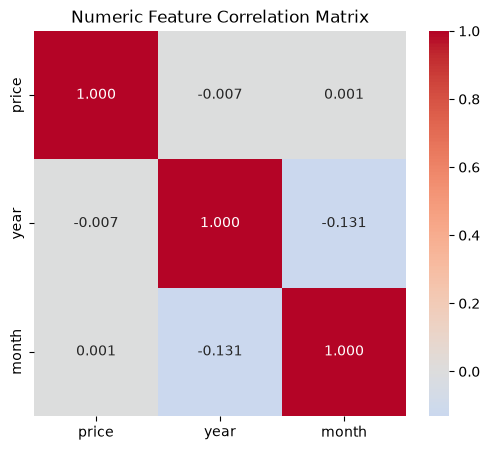

--- property_type ---
                       mean  count
property_type                     
O              1.201365e+06   6167
D              5.106097e+05  23415
S              3.302361e+05  27749

--- old_new ---
                  mean  count
old_new                      
N        414213.046789  93270
Y        411597.331969   8064

--- duration ---
                   mean  count
duration                      
F         433404.395287  78472
L         347417.638527  22862

--- town_city ---
                     mean  count
town_city                       
WINDLESHAM   3.797143e+06      7
LUTTERWORTH  2.530321e+06     33
LEATHERHEAD  2.051554e+06     83

--- area_code ---
                 mean  count
area_code                   
W1K        62029105.4     10
SW1Y       46950000.0      2
W1S        29051750.0      4



In [332]:
# ============================================================
# 6. CORRELATION ANALYSIS
# ============================================================
import seaborn as sns

# ---- 6.1 Numeric correlations: strength and direction of LINEAR relations ----
num_features = ["price", "year", "month"]
corr_matrix = df_clean[num_features].corr()
print("Numeric correlation with price (Pearson):")
print(corr_matrix["price"].sort_values(ascending=False))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".3f")
plt.title("Numeric Feature Correlation Matrix");
plt.show()

# ---- 6.2 Categoricals vs price: mean price by group (correlation ratio / association) ----
cat_vs_price = ["property_type", "old_new", "duration", "town_city", "area_code"]

# Correlation ratio (eta) measures association between a categorical and a numeric target.
# Pearson r is NOT valid for categoricals, so use group-mean spread to gauge signal.
for col in cat_vs_price:
    grp = df_clean.groupby(col, observed=True)["price"].agg(["mean", "count"])
    top = grp.sort_values("mean", ascending=False).head(3)
    print(f"--- {col} ---")
    print(top.to_string())
    print()


In [333]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

# ---- 5.5 Log-transform the target (price is right-skewed) ----
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

preprocessor.fit_transform(X_train)
print("Preprocessed training shape (after one-hot):", preprocessor.transform(X_train).shape)

Train size: 81067 | Test size: 20267


Preprocessed training shape (after one-hot): (81067, 989)


# 3.  Model Training 

In [ ]:
# ============================================================
# 7. CONSISTENT MODEL EVALUATION FRAMEWORK
# ============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# One helper used for EVERY model -> results are comparable across runs.
# Reports metrics on the log-price scale (what we train on) AND on the
# original GBP scale (back-transformed with expm1) for interpretability.
def evaluate_model(model, X_train, y_train_log, X_test, y_test_log, model_name):
    model.fit(X_train, y_train_log)
    pred_log = model.predict(X_test)

    # log-scale metrics
    rmse_log = np.sqrt(mean_squared_error(y_test_log, pred_log))
    mae_log  = mean_absolute_error(y_test_log, pred_log)
    r2_log   = r2_score(y_test_log, pred_log)

    # original-scale metrics (back-transform)
    pred  = np.expm1(pred_log)
    y_real = np.expm1(y_test_log)
    rmse_real = np.sqrt(mean_squared_error(y_real, pred))
    r2_real   = r2_score(y_real, pred)

    result = {
        "model": model_name,
        "RMSE_log": rmse_log, "MAE_log": mae_log, "R2_log": r2_log,
        "RMSE_GBP": rmse_real, "R2_GBP": r2_real,
    }
    print(model_name)
    print(f"  [log scale]  RMSE={rmse_log:.4f}  MAE={mae_log:.4f}  R2={r2_log:.4f}")
    print(f"  [GBP scale]  RMSE={rmse_real:,.0f}  R2={r2_real:.4f}")
    return result

# Results container for the final comparison table
results = []

# ---------------- 7.1 LINEAR REGRESSION BASELINE ----------------
from sklearn.linear_model import LinearRegression

lg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])

results.append(
    evaluate_model(lg_model, X_train, y_train_log, X_test, y_test_log, "LinearRegression")
)


LinearRegression
  [log scale]  RMSE=0.6055  MAE=0.3786  R2=0.4055
  [GBP scale]  RMSE=1,202,998  R2=0.0295


: 

In [ ]:
# ---------------- 7.2 RANDOM FOREST ----------------
# Captures non-linear interactions (type x area) that linear models miss.
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)),
])

results.append(
    evaluate_model(rf_model, X_train, y_train_log, X_test, y_test_log, "RandomForest")
)


In [ ]:
# ---------------- 7.3 GRADIENT BOOSTING ----------------
# Often the strongest sklearn regressor on tabular data.
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(n_estimators=200, random_state=42)),
])

results.append(
    evaluate_model(gb_model, X_train, y_train_log, X_test, y_test_log, "GradientBoosting")
)


In [ ]:
# ============================================================
# 8. MODEL COMPARISON & SELECTION
# ============================================================
results_df = pd.DataFrame(results).set_index("model")

results_df = results_df.sort_values("R2_log", ascending=False)
print("Consistent comparison (sorted by log-scale R2):")
print(results_df.round(4).to_string())

best_name = results_df.index[0]
best_R2_log = results_df["R2_log"].iloc[0]
print()
print(f"Best model: {best_name}  (log R2 = {best_R2_log:.4f})")

# ---- Feature importance of the best tree-based model ----
if best_name in ("RandomForest", "GradientBoosting"):
    best_model = rf_model if best_name == "RandomForest" else gb_model
    reg  = best_model.named_steps["regressor"]
    prep = best_model.named_steps["preprocessor"]
    feat_names = prep.get_feature_names_out()
    imp = pd.Series(reg.feature_importances_, index=feat_names)
    imp = imp.sort_values(ascending=False).head(15)
    print()
    print("Top 15 feature importances:")
    print(imp.to_string())

    plt.figure(figsize=(9, 5))
    imp.plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance - {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout(); plt.show()

# ---- Overfitting check: train vs test R2 ----
if best_name in ("RandomForest", "GradientBoosting"):
    tr_log = best_model.predict(X_train)
    tr_r2 = r2_score(y_train_log, tr_log)
    print()
    print(f"Overfitting check for {best_name}:")
    print(f"  Train R2 (log) = {tr_r2:.4f}  |  Test R2 (log) = {best_R2_log:.4f}")
    print(f"  Gap = {tr_r2 - best_R2_log:.4f}  (large gap suggests overfitting)")


# 4. Performance Matrics and Prediction with new Datas

# 5. Save to Joblib

# 6. fastapi web application

# 7. runnig on Test our application

# 8. Prediction From Frontend Application

# 9. deploy the app using the Docker